# Xenium Replicate 1 to H&E histology

This final notebook aligns 162,033 Xenium mouse-brain cells (query) to the
21-region H&E feature map (reference). The query is Replicate 1 from the
[10x Genomics Fresh Frozen Mouse Brain Xenium dataset](https://www.10xgenomics.com/datasets/fresh-frozen-mouse-brain-replicates-1-standard).
The reference image is control Replicate 1 from the
[Visium CytAssist Post-Xenium Mouse Brain dataset](https://www.10xgenomics.com/datasets/visium-cytassist-gene-expression-libraries-of-post-xenium-mouse-brain-ff-using-the-mouse-whole-transcriptome-probe-set-2-standard).

Only the H&E image-derived structures estimate the transformation. The Visium
expression measurements paired with the image are not alignment inputs; the
paper reserves them for independent molecular-concordance evaluation.

## Input format and notebook order

Run these steps in order:

1. **Single clustering (CSV or AnnData input)** creates a clustered query
   AnnData with `X`, `obsm["spatial"]`, `obs["cluster_raw"]`, and
   `obs["cluster"]`.
2. **H&E image preparation and feature extraction** starts from one image.
3. **H&E image-feature clustering** creates the fixed 21-region raster.
4. This notebook constructs coarse-to-fine ST structures, estimates a global
   pre-alignment, pairs geometrically compatible masks, and runs S-LDDMM.

Set `SPALIGNDE_CLUSTERED_ST_H5AD` and
`SPALIGNDE_DOCUMENTATION_CLUSTER_DIR` only when the outputs live outside the
default tutorial directories.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

import spAlignDE

WORKFLOW_SEED = 0
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = Path(
    os.environ.get(
        "SPALIGNDE_HISTOLOGY_DATA_DIR",
        PROJECT_ROOT / "data" / "cross_modality" / "histology" / "mouse_brain",
    )
).expanduser()
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "histology" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
clustered_default = DATA_DIR / "xenium_rep1_single_clustered.h5ad"
ST_PATH = Path(
    os.environ.get("SPALIGNDE_CLUSTERED_ST_H5AD", clustered_default)
).expanduser()
CLUSTER_DIR = Path(
    os.environ.get(
        "SPALIGNDE_DOCUMENTATION_CLUSTER_DIR",
        OUTPUT_DIR / "histology_clustering",
    )
).expanduser()

adata = spAlignDE.load_single_sample_data(ST_PATH)
histology = spAlignDE.load_histology_clustering(CLUSTER_DIR)
spAlignDE.validate_single_sample_anndata(
    adata,
    cluster_key="cluster",
    require_cluster=True,
)

print(f"Query: {adata.n_obs:,} Xenium cells × {adata.n_vars:,} genes")
print(f"Reference: {histology.n_structures} image-derived structures on a {histology.shape} grid")

Query: 162,033 Xenium cells × 248 genes
Reference: 21 image-derived structures on a (1288, 798) grid


## 1. Build expression-based ST structure levels

The paper hierarchy is built from the original BANKSY labels
(`cluster_raw`), not from H&E pixels or Visium expression. Cluster-average
profiles are compared after variance-based gene selection and Ward linkage.
For this dataset the resulting levels contain 7, 14, 20, and 26 structures;
the 7-structure level is used for H&E correspondence.

,structure column,number of structures,selected
0,cluster_raw_level_k7,7,True
1,cluster_raw_level_k14,14,False
2,cluster_raw_level_k20,20,False
3,cluster_raw_level_k26,26,False


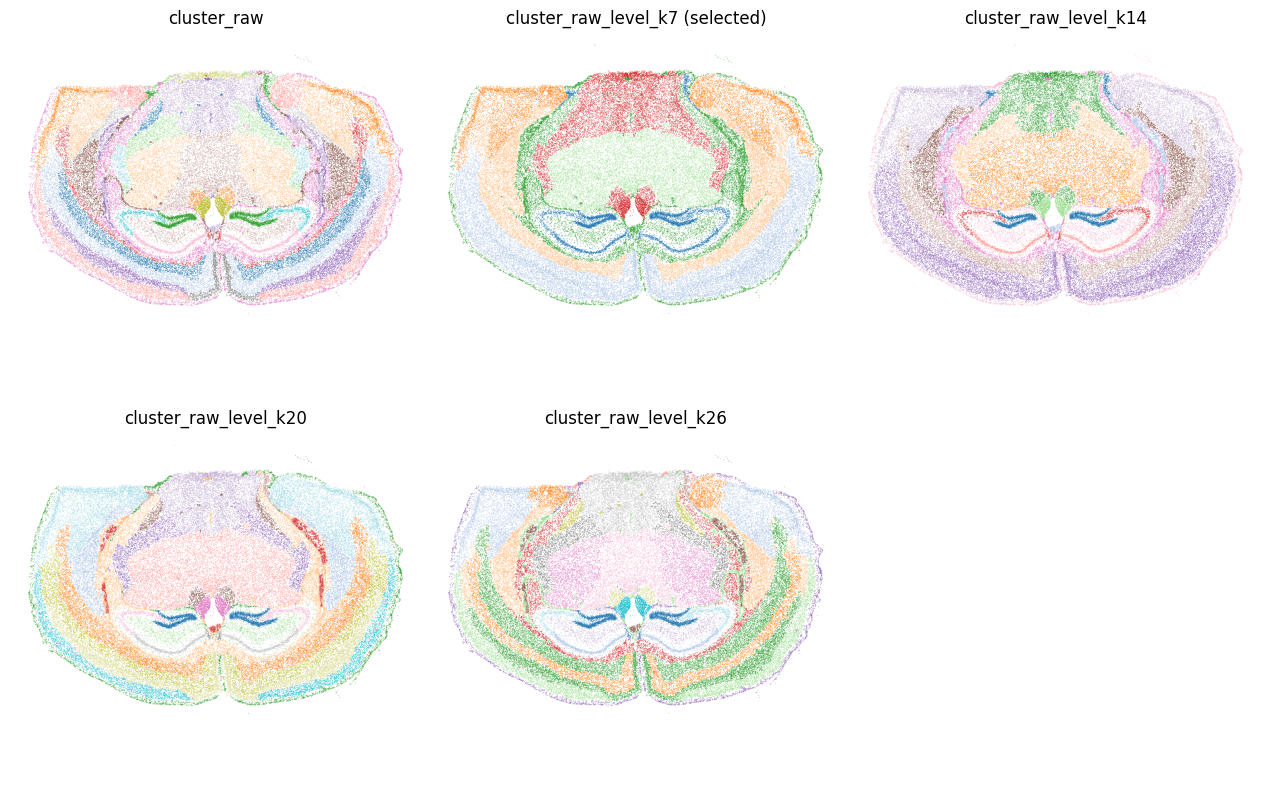

In [3]:
hierarchy_base = "cluster_raw" if "cluster_raw" in adata.obs else "cluster"
adata, hierarchy_columns = spAlignDE.build_st_histology_structures(
    adata,
    config=spAlignDE.STHistologyStructureConfig(
        n_levels=5,
        variance_fraction=0.75,
        min_genes=50,
    ),
    cluster_key=hierarchy_base,
    copy=False,
)
structure_key = next(
    (column for column in hierarchy_columns if column.endswith("_k7")),
    hierarchy_columns[0],
)

display(
    pd.DataFrame(
        {
            "structure column": hierarchy_columns,
            "number of structures": [adata.obs[column].nunique() for column in hierarchy_columns],
            "selected": [column == structure_key for column in hierarchy_columns],
        }
    )
)

fig, axes = spAlignDE.plot_st_histology_structures(
    adata,
    hierarchy_columns,
    cluster_key=hierarchy_base,
    selected_key=structure_key,
)
fig.savefig(FIGURE_DIR / "xenium_st_structure_hierarchy.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_st_structure_hierarchy.svg", bbox_inches="tight")
plt.show()

## 2. Global pre-alignment by tissue-mask overlap

The default searches rotation, isotropic scale, and translation to maximize
whole-tissue mask IoU; reflection is disabled. Always inspect the overlay.
Mask overlap may fail when tissue coverage, orientation, cropping, or tears
differ strongly between modalities. In that case, use the package's
interactive manual panel and save the selected similarity transform before
running S-LDDMM.

Set `SPALIGNDE_HISTOLOGY_PREALIGN=manual` to reproduce the paper's recorded
manual initialization (`scale=0.12`, `theta=85°`).

,value
method,whole_tissue_mask_overlap
scale,0.121794
theta_deg,85.699516
translation_x,794.937349
translation_y,3.57943
iou,0.929147
search_observations,50000


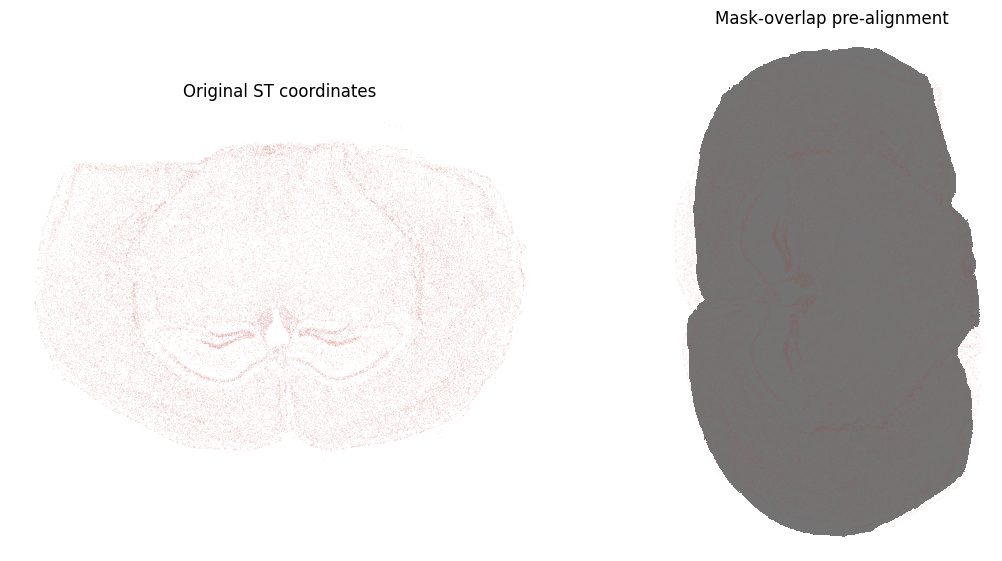

In [4]:
prealign_mode = os.environ.get("SPALIGNDE_HISTOLOGY_PREALIGN", "mask_overlap").lower()
paper_manual = spAlignDE.ManualPrealignmentConfig(
    scale=0.12,
    theta_deg=85.0,
    translation_x=787.84018089,
    translation_y=-9.30873160,
)
prealignment = spAlignDE.prealign_st_to_histology(
    adata,
    histology,
    config=spAlignDE.HistologyPrealignmentConfig(
        method=prealign_mode,
        manual=paper_manual,
    ),
    cluster_key="cluster",
)

display(pd.Series(prealignment.params, name="value").drop(labels="matrix").to_frame())

preview_config = spAlignDE.ManualPrealignmentConfig(
    scale=prealignment.params["scale"],
    theta_deg=prealignment.params["theta_deg"],
    translation_x=prealignment.params["translation_x"],
    translation_y=prealignment.params["translation_y"],
)
fig, axes = spAlignDE.plot_histology_prealignment_preview(
    adata,
    histology,
    config=preview_config,
    transformed_title=(
        "Mask-overlap pre-alignment"
        if prealignment.params["method"] == "whole_tissue_mask_overlap"
        else "Manual pre-alignment"
    ),
)
fig.savefig(FIGURE_DIR / "xenium_to_he_global_prealignment.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_to_he_global_prealignment.svg", bbox_inches="tight")
plt.show()

### Optional interactive manual pre-alignment

If the automatic overlay is anatomically implausible, run:

```python
ui = spAlignDE.interactive_histology_prealignment(
    adata,
    histology,
    initial_config=preview_config,
)
manual_prealignment = ui.apply()
```

The sliders adjust scale, rotation, x translation, and y translation. The
selected values are written under
`adata.uns["spAlignDE"]["st_to_histology"]["prealignment"]`, making the
manual decision reproducible rather than leaving it only in a figure.

In [5]:
if prealignment.params.get("iou") is not None and prealignment.params["iou"] < 0.20:
    print("Low mask IoU: run the interactive manual pre-alignment cell above before continuing.")
else:
    print("Global initialization passed the default mask-overlap QC check.")

Global initialization passed the default mask-overlap QC check.


## 3. Structure pairing and S-LDDMM

ST and H&E structures are rasterized on the shared feature grid. Candidate
pairs use the paper weights for SDF agreement, Chamfer similarity, Dice, area,
and thickness (`0.20, 0.40, 0.15, 0.25, 0.00`). ASD is not included in the
composite score; its raw raster-space value is used only as an independent QC
gate. Pairs must have score ≥ 0.40 and ASD ≤ 30 pixels. Accepted pairs become
 continuous signed-distance channels for a single-stage S-LDDMM fit.

The run retains the final optimizer iterate (`restore_best_checkpoint=False`),
which is the package-wide default and avoids comparing energies across EM
intensity updates with different objective scales.

Users can change the five normalized weights in
`STHistologyAlignmentConfig`. Tune them only after checking the coordinate
scale, global pre-alignment, structure masks, and candidate-pair overlays. See
the website [Cross-modality pairing weights](https://dsong-lab.github.io/spAlignDE/tutorials/parameter_tuning.html#cross-modality-pairing-weights)
section for the effect of each component and a recommended tuning sequence.

[area-only gate] mode=bbox, q=0.15, threshold=24320.871, n_detail=1


[mask cleanup] cluster=1 n_cc 5→2 largest% 0.46→0.52
[mask cleanup] cluster=2 n_cc 2→2 largest% 0.51→0.51


[mask cleanup] cluster=3 n_cc 2→2 largest% 0.54→0.54
[mask cleanup] cluster=4 n_cc 2→2 largest% 0.50→0.50


[mask cleanup] cluster=5 n_cc 35→2 largest% 0.44→0.61


[mask cleanup] cluster=7 n_cc 3→1 largest% 0.90→1.00
shape_type_used
detail    1
normal    6
Name: n_clusters, dtype: int64


...

[LDDMM] iter 1/300 E=4.024298e+03 EM=4.024298e+03 ER=0.000000e+00


[LDDMM] iter 101/300 E=2.904339e+03 EM=2.904333e+03 ER=6.658846e-03


[LDDMM] iter 201/300 E=2.236091e+03 EM=2.236079e+03 ER=1.231787e-02


[LDDMM] iter 300/300 E=1.861402e+03 EM=1.861386e+03 ER=1.566637e-02
[LDDMM] done in 34.3s. finalE=1.861402e+03


,st,he,align_score,dice,area_sim,asd
0,2,1,0.646565,0.711963,0.976780,23.972335
1,1,5,0.622647,0.247610,0.814431,11.142899


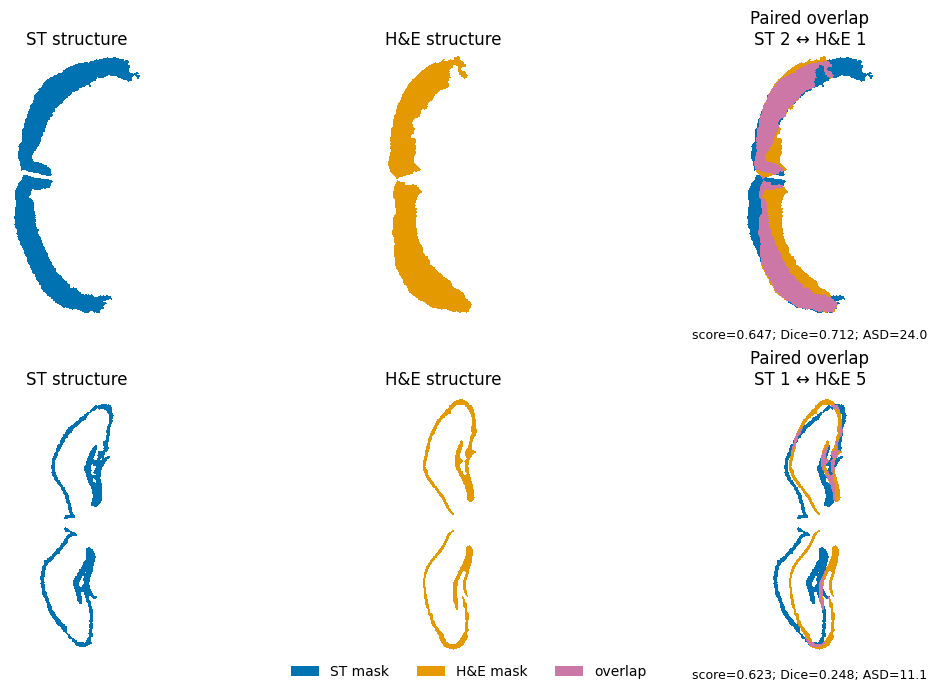

,st,he,stage,dice,iou,asd,hd
0,2,1,before,0.712074,0.552885,23.934917,172.011628
1,2,1,after,0.854095,0.745345,11.345230,50.358713
2,1,5,before,0.253308,0.145022,11.507431,45.177428
3,1,5,after,0.571604,0.400172,3.305840,29.068884


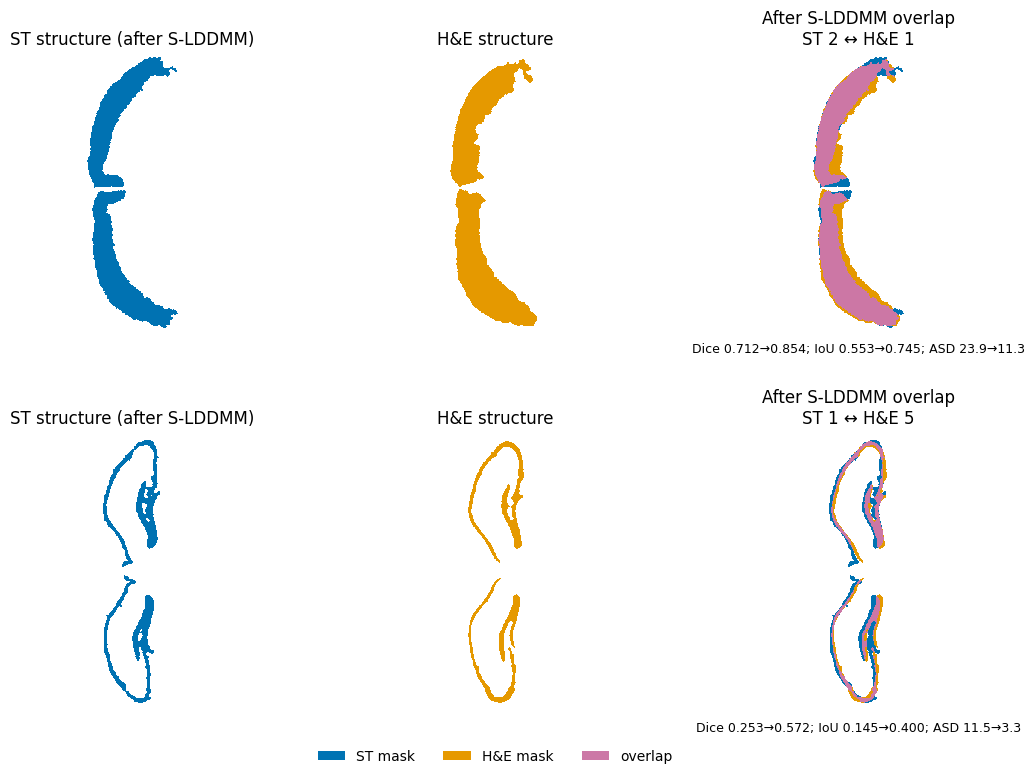

In [6]:
result = spAlignDE.align_st_to_histology(
    prealignment,
    config=spAlignDE.STHistologyAlignmentConfig(
        pairing_weight_sdf=0.20,
        pairing_weight_chamfer=0.40,
        pairing_weight_dice=0.15,
        pairing_weight_area=0.25,
        pairing_weight_thickness=0.00,
        pair_score_threshold=0.40,
        pair_asd_threshold=30.0,
        time_steps=5,
        kernel_scale=60.0,
        velocity_grid_spacing=6.0,
        iterations=300,
        momentum_lr=2e3,
        restore_best_checkpoint=False,
        device=None,
        dtype="float64",
    ),
    cluster_key="cluster",
    structure_key=structure_key,
    output_dir=OUTPUT_DIR / "alignment",
)

pair_columns = [
    column
    for column in ("st", "he", "align_score", "dice", "area_sim", "asd")
    if column in result.matched_pairs
]
display(result.matched_pairs[pair_columns])

# Plot the exact cleaned binary channels supplied to S-LDDMM.  The final
# channel is the whole-tissue support and is intentionally omitted here.
from matplotlib.patches import Patch

source_masks = result.context["source_binary"][:-1].astype(bool)
target_masks = result.context["target_binary"][:-1].astype(bool)
source_color = (0.00, 0.45, 0.70, 1.00)
target_color = (0.90, 0.60, 0.00, 1.00)
overlap_color = (0.80, 0.47, 0.65, 1.00)

fig, axes = plt.subplots(
    len(result.matched_pairs),
    3,
    figsize=(11, 3.4 * len(result.matched_pairs)),
    constrained_layout=True,
    squeeze=False,
)
for row_index, ((_, pair), source_mask, target_mask) in enumerate(
    zip(result.matched_pairs.iterrows(), source_masks, target_masks, strict=True)
):
    union = source_mask | target_mask
    yy, xx = union.nonzero()
    pad = 18
    y0, y1 = max(0, yy.min() - pad), min(union.shape[0], yy.max() + pad + 1)
    x0, x1 = max(0, xx.min() - pad), min(union.shape[1], xx.max() + pad + 1)

    source_rgba = plt.cm.colors.to_rgba_array([source_color])[0]
    target_rgba = plt.cm.colors.to_rgba_array([target_color])[0]
    panels = []
    for mask, color in ((source_mask, source_rgba), (target_mask, target_rgba)):
        image = 1.0 * (~mask)[..., None] * (1.0, 1.0, 1.0, 1.0)
        image[mask] = color
        panels.append(image)
    overlap_image = panels[1].copy()
    overlap_image[source_mask] = source_color
    overlap_image[source_mask & target_mask] = overlap_color
    panels.append(overlap_image)

    titles = (
        "ST structure",
        "H&E structure",
        f"Paired overlap\nST {pair['st']} ↔ H&E {pair['he']}",
    )
    for axis, image, title in zip(axes[row_index], panels, titles, strict=True):
        axis.imshow(image[y0:y1, x0:x1], origin="lower", interpolation="nearest")
        axis.set_title(title)
        axis.axis("off")
    axes[row_index, 2].text(
        0.5,
        -0.04,
        f"score={pair['align_score']:.3f}; Dice={pair['dice']:.3f}; ASD={pair['asd']:.1f}",
        transform=axes[row_index, 2].transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

fig.legend(
    handles=(
        Patch(facecolor=source_color, label="ST mask"),
        Patch(facecolor=target_color, label="H&E mask"),
        Patch(facecolor=overlap_color, label="overlap"),
    ),
    loc="lower center",
    ncol=3,
    frameon=False,
)
fig.savefig(FIGURE_DIR / "xenium_he_paired_feature_overlap.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_he_paired_feature_overlap.svg", bbox_inches="tight")
plt.show()

# Re-rasterize the accepted ST structures after the final deformation and
# compare pair-level Dice, IoU, and ASD against the pre-aligned masks above.
fig, axes, pair_overlap_metrics = spAlignDE.plot_st_histology_pair_overlap(
    result,
    stage="after",
)
display(pair_overlap_metrics[
    ["st", "he", "stage", "dice", "iou", "asd", "hd"]
])
fig.savefig(
    FIGURE_DIR / "xenium_he_paired_feature_overlap_after_lddmm.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "xenium_he_paired_feature_overlap_after_lddmm.svg",
    bbox_inches="tight",
)
plt.show()

## 4. Before and after histology-guided alignment

Both panels show all Xenium cells in blue over the same original color H&E
image, matching the paper visualization. The first panel is the global
initialization; the second is the final structure-guided S-LDDMM result.

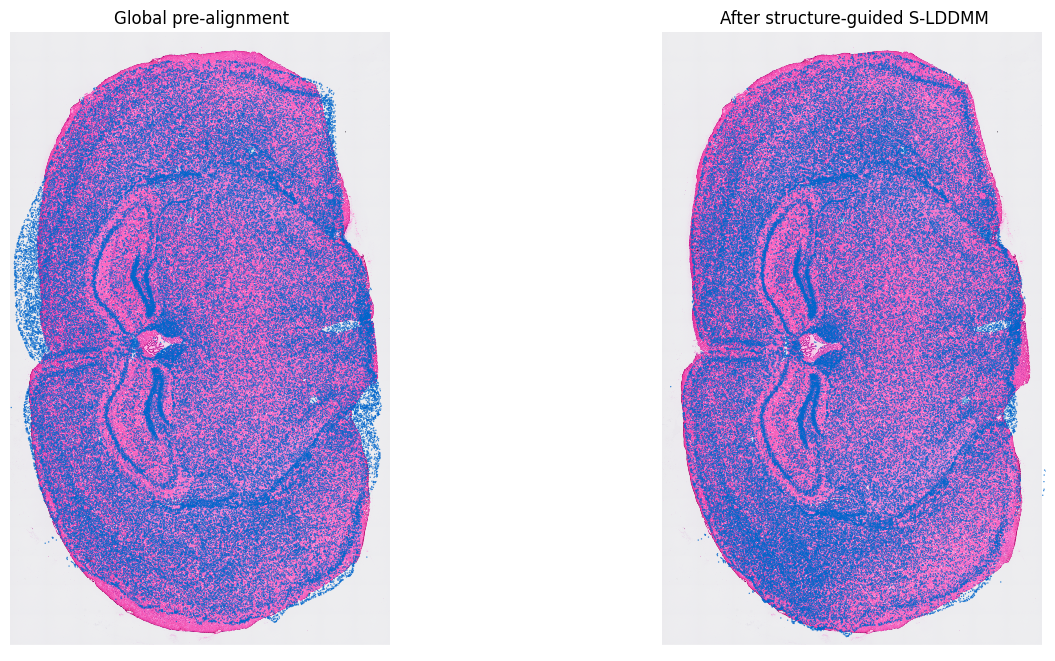

In [7]:
fig, axes = spAlignDE.plot_st_histology_alignment(
    result,
    cluster_key="cluster",
    point_size=1.0,
    alpha=0.8,
    color_by_cluster=False,
    point_color="#0066CC",
    figsize=(13, 6.5),
)
fig.savefig(FIGURE_DIR / "xenium_to_he_before_after.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_to_he_before_after.svg", bbox_inches="tight")
plt.show()

## 5. Standardized output

The original `X`, observation order, metadata, and `obsm["spatial"]` are
preserved. Alignment adds `x_prealigned`, `y_prealigned`, `x_aligned`, and
`y_aligned`. Run parameters are stored only under
`adata.uns["spAlignDE"]`. The final AnnData, pair table, filter summary and
JSON run summary are written to `tutorials/cross_modality/histology/output/alignment/`.

In [8]:
display(result.adata.obs[["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]].describe())
display(pd.Series(result.adata.uns["spAlignDE"]["st_to_histology"]["alignment"], name="value").to_frame())
print("Saved: tutorials/cross_modality/histology/output/alignment/st_to_histology_aligned.h5ad")

,x_prealigned,y_prealigned,x_aligned,y_aligned
count,162033.000000,162033.000000,162033.000000,162033.000000
mean,393.487470,656.695614,381.906370,665.619964
std,196.227468,302.458530,181.070643,313.371936
min,-1.711466,58.138929,17.388879,42.725467
25%,232.798526,402.695841,233.666528,395.566895
50%,386.810463,658.079291,364.049992,666.198348
75%,559.309331,918.267701,526.400268,947.250502
max,835.657562,1238.503827,835.291703,1257.143332


,value
cluster_key,cluster
structure_key,cluster_raw_level_k7
spatial_key,spatial
histology_grid_shape_hw,"[1288, 798]"
histology_pixels_per_grid_unit,16
matched_pairs,2
parameters,"{'pairing_weight_sdf': 0.2, 'pairing_weight_ch..."


Saved: tutorials/cross_modality/histology/output/alignment/st_to_histology_aligned.h5ad
